# Project Overview

This notebook builds and compares fraud detection models on the credit card dataset while preserving the original pipeline, outputs, and artifacts.


# Library Imports

Common analysis and modeling libraries are grouped here so the rest of the notebook stays focused on the workflow.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import ADASYN, SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


# Data Loading


In [ ]:
# Load the dataset
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


# Exploratory Data Analysis


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


# Data Cleaning


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


# Feature Engineering


In [ ]:
df['Class'] = df['Class'].astype('int')

In [ ]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [ ]:
(df['Class'].value_counts(normalize=True)*100).round(2)

,proportion
Class,
0,99.83
1,0.17


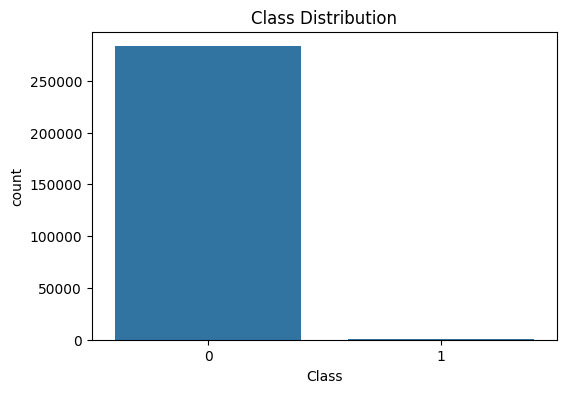

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.show()

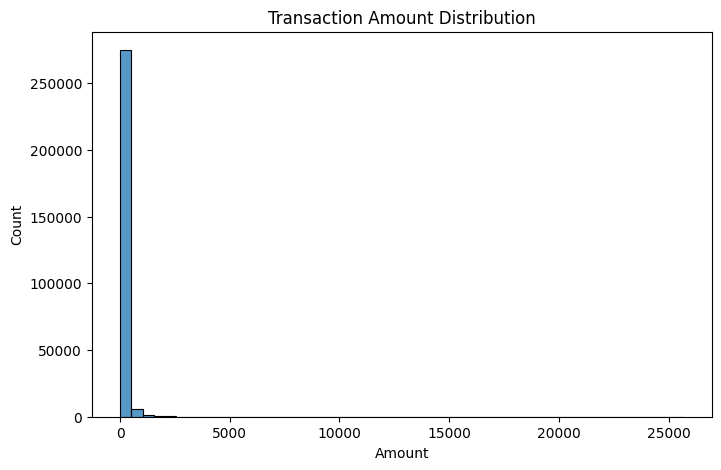

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

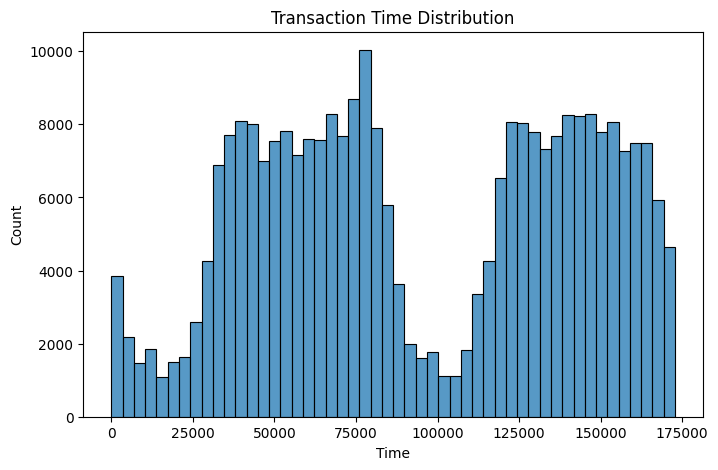

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

In [ ]:
corr_matrix = df.corr()
corr_matrix


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,...,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,...,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,...,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,...,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,...,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


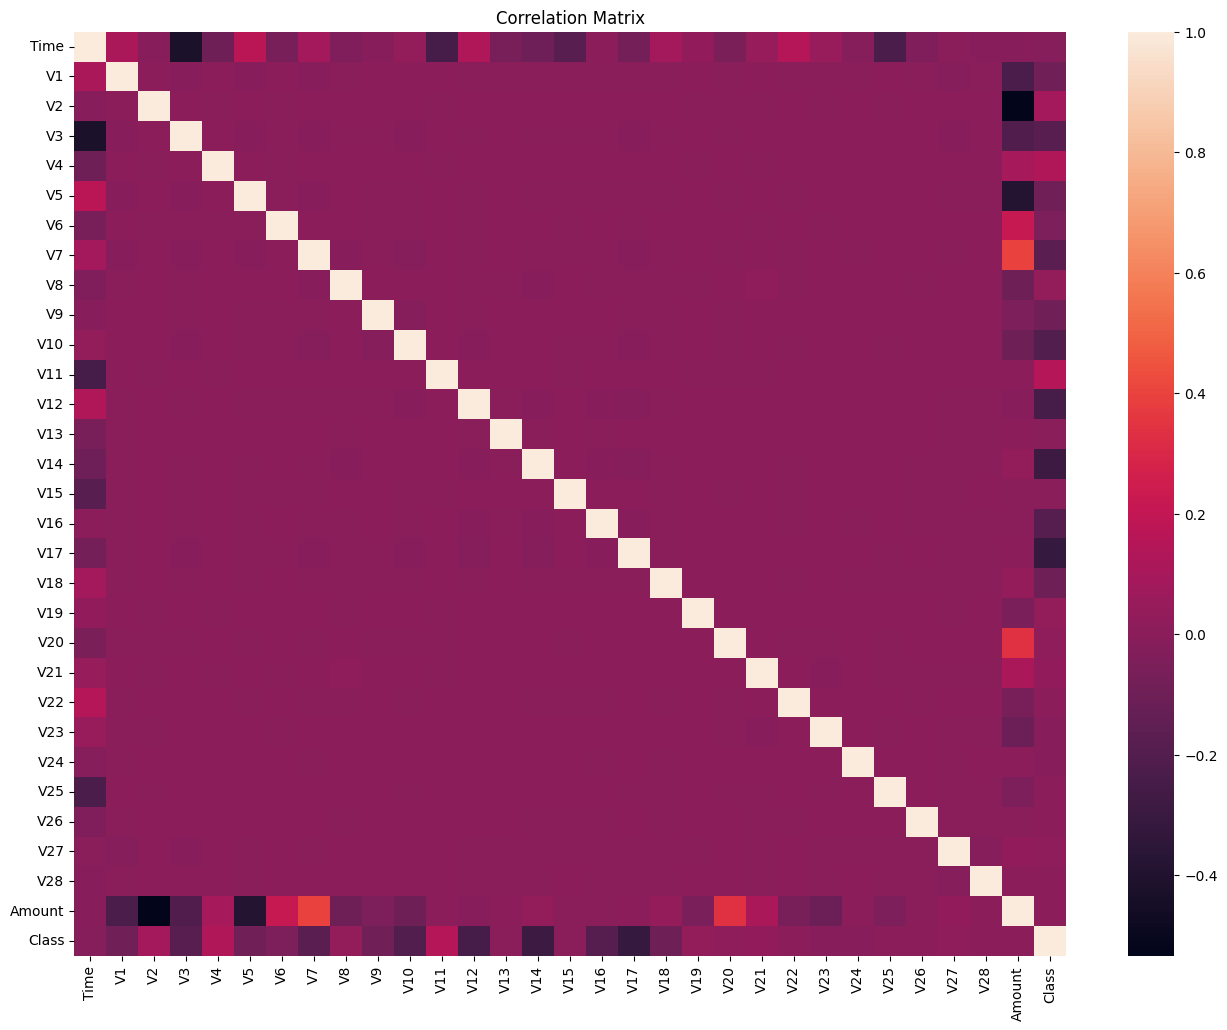

In [ ]:
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]


# Data Preprocessing


In [ ]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# Verify the train/test split shapes
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)


(226980, 30)
(56746, 30)
(226980,)
(56746,)


In [ ]:
# Standardize features for model training
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])


[[ 1.04549909  1.14719836 -1.04203246 -1.42882122 -1.81782372  0.72719752
   2.69567651 -1.48930967  0.73574582 -1.1527044   1.46294508 -0.23144624
  -0.71106413  0.36640847 -0.3267679   0.3107816  -0.66265092  0.4532502
  -0.21858679 -0.39183752 -0.42719557 -0.20857295 -0.0682055   0.44537866
   1.13020245 -0.42036292 -0.33128128  0.09278213 -0.15619266 -0.22943372]
 [-0.29869002 -0.67791131  0.99194846  0.39466759 -0.02564188 -0.30119792
  -0.72824     0.17561517  0.62906964 -1.15629021 -0.44768035  1.41072091
   1.77590449  1.26254666  0.90568792 -0.29213577  0.44924302 -0.3139793
  -0.41300753  0.48143447 -0.08983279 -0.3322481  -1.30714055  0.51803572
   0.85106892 -1.36733752 -0.55425458 -0.04986389  0.15383143 -0.33119698]
 [ 0.67839667  0.97765362  0.0162054  -1.38670055  0.09268839  0.85061266
   0.45882253 -0.01987242  0.15436983  0.26205551 -0.46178004  1.50481822
   1.04711116  0.4792321  -0.72078502  1.05351845 -0.31917661  0.94169101
  -0.18983101 -1.2233426  -0.27797265 

In [ ]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
# Train the baseline logistic regression model
baseline_model = LogisticRegression(random_state=42, max_iter=1000)


# Model Training


In [ ]:
baseline_model.fit(X_train_scaled, y_train )

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = baseline_model.predict( X_test_scaled)

In [ ]:
y_prob = baseline_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

precision = precision_score( y_test, y_pred )
print("Precision:", precision)

recall = recall_score( y_test, y_pred )
print("Recall:", recall)

f1 = f1_score( y_test, y_pred )
print("F1 Score:", f1)

mcc = matthews_corrcoef( y_test, y_pred )
print("MCC:", mcc)

cm = confusion_matrix( y_test, y_pred )
print(cm)

print( classification_report( y_test, y_pred ))


Accuracy: 0.9991188806259472
Precision: 0.8461538461538461
Recall: 0.5789473684210527
F1 Score: 0.6875
MCC: 0.6995146454017752
[[56641    10]
 [   40    55]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
# Apply SMOTE to the scaled training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(y_train.value_counts(), y_train_smote.value_counts())


Class
0    226602
1       378
Name: count, dtype: int64 Class
0    226602
1    226602
Name: count, dtype: int64


In [ ]:
smote_model = LogisticRegression( random_state=42, max_iter=1000)
smote_model.fit( X_train_smote, y_train_smote )

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_smote = smote_model.predict(X_test_scaled)

In [ ]:
y_prob_smote = smote_model.predict_proba( X_test_scaled )[:,1]

In [ ]:
accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)

precision_smote = precision_score(
    y_test,
    y_pred_smote
)

recall_smote = recall_score(
    y_test,
    y_pred_smote
)

f1_smote = f1_score(
    y_test,
    y_pred_smote
)

mcc_smote = matthews_corrcoef(
    y_test,
    y_pred_smote
)

print(f"Accuracy : {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall   : {recall_smote:.4f}")
print(f"F1 Score : {f1_smote:.4f}")
print(f"MCC      : {mcc_smote:.4f}")

Accuracy : 0.9737
Precision: 0.0530
Recall   : 0.8737
F1 Score : 0.1000
MCC      : 0.2116


In [ ]:
cm_smote = confusion_matrix( y_test, y_pred_smote )
print(cm_smote)
print( classification_report( y_test, y_pred_smote ) )

[[55169  1482]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [ ]:
# Apply ADASYN to the scaled training data
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(y_train_adasyn.value_counts())


Class
1    226630
0    226602
Name: count, dtype: int64


In [ ]:
adasyn_model = LogisticRegression( random_state=42, max_iter=1000)
adasyn_model.fit( X_train_adasyn, y_train_adasyn )

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_adasyn = adasyn_model.predict( X_test_scaled )
y_prob_adasyn = adasyn_model.predict_proba( X_test_scaled )[:,1]

In [ ]:
accuracy_adasyn = accuracy_score(
    y_test,
    y_pred_adasyn
)

precision_adasyn = precision_score(
    y_test,
    y_pred_adasyn
)

recall_adasyn = recall_score(
    y_test,
    y_pred_adasyn
)

f1_adasyn = f1_score(
    y_test,
    y_pred_adasyn
)

mcc_adasyn = matthews_corrcoef(
    y_test,
    y_pred_adasyn
)
print(f"Accuracy : {accuracy_adasyn:.4f}")
print(f"Precision: {precision_adasyn:.4f}")
print(f"Recall   : {recall_adasyn:.4f}")
print(f"F1 Score : {f1_adasyn:.4f}")
print(f"MCC      : {mcc_adasyn:.4f}")

Accuracy : 0.9085
Precision: 0.0165
Recall   : 0.9158
F1 Score : 0.0324
MCC      : 0.1161


In [ ]:
cm_adasyn = confusion_matrix( y_test, y_pred_adasyn)
print(cm_adasyn)
print( classification_report( y_test, y_pred_adasyn))

[[51467  5184]
 [    8    87]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     56651
           1       0.02      0.92      0.03        95

    accuracy                           0.91     56746
   macro avg       0.51      0.91      0.49     56746
weighted avg       1.00      0.91      0.95     56746



# Model Evaluation and Comparison


In [ ]:
comparison_df = pd.DataFrame({ "Model": [ "Baseline", "SMOTE", "ADASYN" ],
              "Accuracy": [ accuracy, accuracy_smote, accuracy_adasyn ],
              "Precision": [ precision, precision_smote, precision_adasyn ],
               "Recall": [ recall, recall_smote, recall_adasyn ],
               "F1 Score": [ f1, f1_smote, f1_adasyn ],
               "MCC": [ mcc, mcc_smote, mcc_adasyn ] })

comparison_df


,Model,Accuracy,Precision,Recall,F1 Score,MCC
0,Baseline,0.999119,0.846154,0.578947,0.687500,0.699515
1,SMOTE,0.973672,0.053035,0.873684,0.100000,0.211576
2,ADASYN,0.908505,0.016505,0.915789,0.032426,0.116090


In [ ]:
weighted_lr = LogisticRegression( class_weight="balanced", random_state=42, max_iter=1000)
weighted_lr.fit( X_train_scaled, y_train )

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred_weighted_lr = weighted_lr.predict(X_test_scaled)
y_prob_weighted_lr = weighted_lr.predict_proba( X_test_scaled )[:,1]

In [ ]:
accuracy_weighted_lr = accuracy_score( y_test, y_pred_weighted_lr )
precision_weighted_lr = precision_score( y_test, y_pred_weighted_lr )
recall_weighted_lr = recall_score( y_test, y_pred_weighted_lr )
f1_weighted_lr = f1_score( y_test, y_pred_weighted_lr )
mcc_weighted_lr = matthews_corrcoef( y_test, y_pred_weighted_lr )

print(f"Accuracy : {accuracy_weighted_lr:.4f}")
print(f"Precision: {precision_weighted_lr:.4f}")
print(f"Recall   : {recall_weighted_lr:.4f}")
print(f"F1 Score : {f1_weighted_lr:.4f}")
print(f"MCC      : {mcc_weighted_lr:.4f}")

Accuracy : 0.9753
Precision: 0.0564
Recall   : 0.8737
F1 Score : 0.1059
MCC      : 0.2184


In [ ]:
# Train a class-weighted random forest model
weighted_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
weighted_rf.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred_weighted_rf = weighted_rf.predict(X_test_scaled)
y_prob_weighted_rf = weighted_rf.predict_proba( X_test_scaled )[:,1]

In [ ]:
accuracy_weighted_rf = accuracy_score( y_test, y_pred_weighted_rf )
precision_weighted_rf = precision_score( y_test, y_pred_weighted_rf )
recall_weighted_rf = recall_score( y_test, y_pred_weighted_rf )
f1_weighted_rf = f1_score( y_test, y_pred_weighted_rf )
mcc_weighted_rf = matthews_corrcoef( y_test, y_pred_weighted_rf )

print(f"Accuracy : {accuracy_weighted_rf:.4f}")
print(f"Precision: {precision_weighted_rf:.4f}")
print(f"Recall : {recall_weighted_rf:.4f}")
print(f"F1 Score : {f1_weighted_rf:.4f}")
print(f"MCC : {mcc_weighted_rf:.4f}")

Accuracy : 0.9995
Precision: 0.9714
Recall : 0.7158
F1 Score : 0.8242
MCC : 0.8336


In [ ]:
comparison_df_extended = pd.DataFrame({ "Model": [ "Baseline Logistic Regression", "SMOTE Logistic Regression",
                                      "ADASYN Logistic Regression", "Weighted Logistic Regression", "Weighted Random Forest" ]
                          , "Accuracy": [ accuracy, accuracy_smote, accuracy_adasyn, accuracy_weighted_lr, accuracy_weighted_rf ],
                            "Precision": [ precision, precision_smote, precision_adasyn, precision_weighted_lr, precision_weighted_rf ],
                            "Recall": [ recall, recall_smote, recall_adasyn, recall_weighted_lr, recall_weighted_rf ],
                            "F1 Score": [ f1, f1_smote, f1_adasyn, f1_weighted_lr, f1_weighted_rf ],
                            "MCC": [ mcc, mcc_smote, mcc_adasyn, mcc_weighted_lr, mcc_weighted_rf ] })
comparison_df_extended


,Model,Accuracy,Precision,Recall,F1 Score,MCC
0,Baseline Logistic Regression,0.999119,0.846154,0.578947,0.687500,0.699515
1,SMOTE Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.211576
2,ADASYN Logistic Regression,0.908505,0.016505,0.915789,0.032426,0.116090
3,Weighted Logistic Regression,0.975311,0.056386,0.873684,0.105935,0.218395
4,Weighted Random Forest,0.999489,0.971429,0.715789,0.824242,0.833644


In [ ]:
# Train a balanced random forest model
brf = BalancedRandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
brf.fit(X_train_scaled, y_train)


BalancedRandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred_brf = brf.predict( X_test_scaled)
y_prob_brf = brf.predict_proba( X_test_scaled )[:,1]

In [ ]:
accuracy_brf = accuracy_score( y_test, y_pred_brf)
precision_brf = precision_score( y_test, y_pred_brf)
recall_brf = recall_score( y_test, y_pred_brf)
f1_brf = f1_score( y_test, y_pred_brf)
mcc_brf = matthews_corrcoef( y_test, y_pred_brf)

print(f"Accuracy : {accuracy_brf:.4f}")
print(f"Precision: {precision_brf:.4f}")
print(f"Recall : {recall_brf:.4f}")
print(f"F1 Score : {f1_brf:.4f}")
print(f"MCC : {mcc_brf:.4f}")

Accuracy : 0.9879
Precision: 0.1052
Recall : 0.8316
F1 Score : 0.1868
MCC : 0.2932


In [ ]:
cm_brf = confusion_matrix( y_test, y_pred_brf )
print(cm_brf)
print( classification_report( y_test, y_pred_brf ))

[[55979   672]
 [   16    79]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.11      0.83      0.19        95

    accuracy                           0.99     56746
   macro avg       0.55      0.91      0.59     56746
weighted avg       1.00      0.99      0.99     56746



In [ ]:
comparison_df_brf = pd.DataFrame({ "Model": [ "Baseline Logistic Regression", "SMOTE Logistic Regression", "ADASYN Logistic Regression",
                                      "Weighted Logistic Regression", "Weighted Random Forest", "Balanced Random Forest" ],
                           "Accuracy": [ accuracy, accuracy_smote, accuracy_adasyn,
                                        accuracy_weighted_lr, accuracy_weighted_rf, accuracy_brf ],
                            "Precision": [ precision, precision_smote, precision_adasyn,
                                          precision_weighted_lr, precision_weighted_rf, precision_brf ],
                            "Recall": [ recall, recall_smote, recall_adasyn,
                                       recall_weighted_lr, recall_weighted_rf, recall_brf ],
                            "F1 Score": [ f1, f1_smote, f1_adasyn,
                                         f1_weighted_lr, f1_weighted_rf, f1_brf ],
                            "MCC": [ mcc, mcc_smote, mcc_adasyn, mcc_weighted_lr, mcc_weighted_rf, mcc_brf ] })
comparison_df_brf


,Model,Accuracy,Precision,Recall,F1 Score,MCC
0,Baseline Logistic Regression,0.999119,0.846154,0.578947,0.687500,0.699515
1,SMOTE Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.211576
2,ADASYN Logistic Regression,0.908505,0.016505,0.915789,0.032426,0.116090
3,Weighted Logistic Regression,0.975311,0.056386,0.873684,0.105935,0.218395
4,Weighted Random Forest,0.999489,0.971429,0.715789,0.824242,0.833644
5,Balanced Random Forest,0.987876,0.105193,0.831579,0.186761,0.293248


In [ ]:
negative_class = y_train.value_counts()[0]
positive_class = y_train.value_counts()[1]
scale_pos_weight = negative_class / positive_class
print("Scale Positive Weight:", scale_pos_weight)

Scale Positive Weight: 599.4761904761905


In [ ]:
xgb_model = XGBClassifier( objective="binary:logistic", scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss" )
xgb_model.fit( X_train_scaled, y_train )

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict( X_test_scaled )
y_prob_xgb = xgb_model.predict_proba( X_test_scaled )[:, 1]

In [ ]:
accuracy_xgb = accuracy_score( y_test, y_pred_xgb )
precision_xgb = precision_score( y_test, y_pred_xgb )
recall_xgb = recall_score( y_test, y_pred_xgb )
f1_xgb = f1_score( y_test, y_pred_xgb )
mcc_xgb = matthews_corrcoef( y_test, y_pred_xgb )

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"MCC      : {mcc_xgb:.4f}")

Accuracy : 0.9996
Precision: 0.9737
Recall   : 0.7789
F1 Score : 0.8655
MCC      : 0.8707


In [ ]:
cm_xgb = confusion_matrix( y_test, y_pred_xgb )
print(cm_xgb)

[[56649     2]
 [   21    74]]


In [ ]:
print( classification_report( y_test, y_pred_xgb ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.78      0.87        95

    accuracy                           1.00     56746
   macro avg       0.99      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
import joblib
joblib.dump( xgb_model, "xgboost_fraud_detector.pkl" )

loaded_model = joblib.load( "xgboost_fraud_detector.pkl" )
print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
# Prepare precision-recall curve inputs

# Baseline Logistic Regression
precision_curve_base, recall_curve_base, _ = precision_recall_curve(
    y_test, y_prob
)
ap_base = average_precision_score(y_test, y_prob)

# SMOTE Logistic Regression
precision_curve_sm, recall_curve_sm, _ = precision_recall_curve(
    y_test, y_prob_smote
)
ap_sm = average_precision_score(y_test, y_prob_smote)

# ADASYN Logistic Regression
precision_curve_ad, recall_curve_ad, _ = precision_recall_curve(
    y_test, y_prob_adasyn
)
ap_ad = average_precision_score(y_test, y_prob_adasyn)

# Weighted Logistic Regression
precision_curve_wlr, recall_curve_wlr, _ = precision_recall_curve(
    y_test, y_prob_weighted_lr
)
ap_wlr = average_precision_score(y_test, y_prob_weighted_lr)

# Weighted Random Forest
precision_curve_wrf, recall_curve_wrf, _ = precision_recall_curve(
    y_test, y_prob_weighted_rf
)
ap_wrf = average_precision_score(y_test, y_prob_weighted_rf)

# Balanced Random Forest
precision_curve_brf, recall_curve_brf, _ = precision_recall_curve(
    y_test, y_prob_brf
)
ap_brf = average_precision_score(y_test, y_prob_brf)

# XGBoost
precision_curve_xgb, recall_curve_xgb, _ = precision_recall_curve(
    y_test, y_prob_xgb
)
ap_xgb = average_precision_score(y_test, y_prob_xgb)


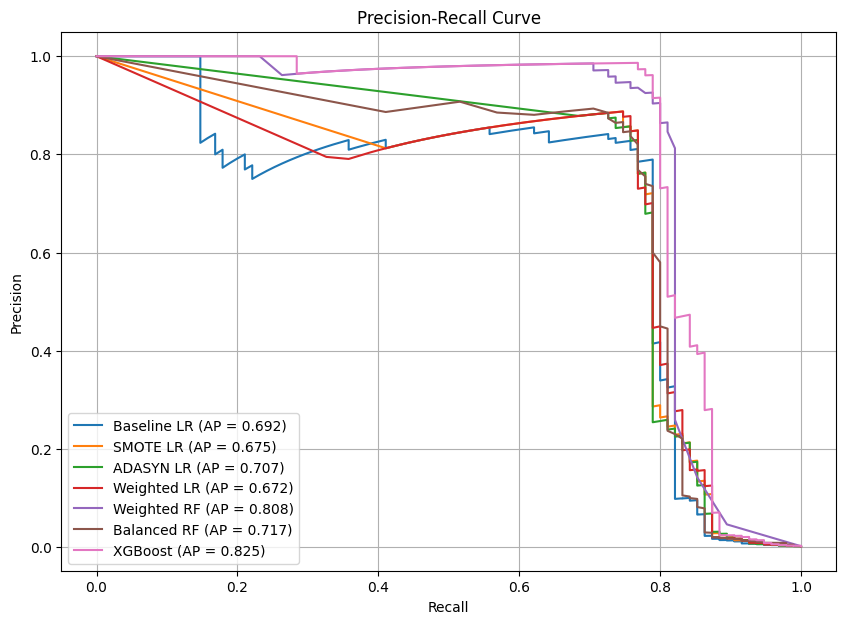

In [ ]:
plt.figure(figsize=(10, 7))

plt.plot(
    recall_curve_base,
    precision_curve_base,
    label=f"Baseline LR (AP = {ap_base:.3f})"
)

plt.plot(
    recall_curve_sm,
    precision_curve_sm,
    label=f"SMOTE LR (AP = {ap_sm:.3f})"
)

plt.plot(
    recall_curve_ad,
    precision_curve_ad,
    label=f"ADASYN LR (AP = {ap_ad:.3f})"
)

plt.plot(
    recall_curve_wlr,
    precision_curve_wlr,
    label=f"Weighted LR (AP = {ap_wlr:.3f})"
)

plt.plot(
    recall_curve_wrf,
    precision_curve_wrf,
    label=f"Weighted RF (AP = {ap_wrf:.3f})"
)

plt.plot(
    recall_curve_brf,
    precision_curve_brf,
    label=f"Balanced RF (AP = {ap_brf:.3f})"
)

plt.plot(
    recall_curve_xgb,
    precision_curve_xgb,
    label=f"XGBoost (AP = {ap_xgb:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="best")

plt.grid(True)

plt.show()

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline LR",
        "SMOTE LR",
        "ADASYN LR",
        "Weighted LR",
        "Weighted RF",
        "Balanced RF",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy,
        accuracy_smote,
        accuracy_adasyn,
        accuracy_weighted_lr,
        accuracy_weighted_rf,
        accuracy_brf,
        accuracy_xgb
    ],

    "Precision": [
        precision,
        precision_smote,
        precision_adasyn,
        precision_weighted_lr,
        precision_weighted_rf,
        precision_brf,
        precision_xgb
    ],

    "Recall": [
        recall,
        recall_smote,
        recall_adasyn,
        recall_weighted_lr,
        recall_weighted_rf,
        recall_brf,
        recall_xgb
    ],

    "F1 Score": [
        f1,
        f1_smote,
        f1_adasyn,
        f1_weighted_lr,
        f1_weighted_rf,
        f1_brf,
        f1_xgb
    ],

    "MCC": [
        mcc,
        mcc_smote,
        mcc_adasyn,
        mcc_weighted_lr,
        mcc_weighted_rf,
        mcc_brf,
        mcc_xgb
    ],

    "Average Precision": [
        ap_base,
        ap_sm,
        ap_ad,
        ap_wlr,
        ap_wrf,
        ap_brf,
        ap_xgb
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score,MCC,Average Precision
0,Baseline LR,0.999119,0.846154,0.578947,0.687500,0.699515,0.691967
1,SMOTE LR,0.973672,0.053035,0.873684,0.100000,0.211576,0.675041
2,ADASYN LR,0.908505,0.016505,0.915789,0.032426,0.116090,0.707303
3,Weighted LR,0.975311,0.056386,0.873684,0.105935,0.218395,0.671924
4,Weighted RF,0.999489,0.971429,0.715789,0.824242,0.833644,0.807769
5,Balanced RF,0.987876,0.105193,0.831579,0.186761,0.293248,0.717462
6,XGBoost,0.999595,0.973684,0.778947,0.865497,0.870704,0.825108


# Artifact Saving


In [ ]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [ ]:
joblib.dump(
    baseline_model,
    "baseline_lr.pkl"
)

['baseline_lr.pkl']

In [ ]:
joblib.dump(
    smote_model,
    "smote_lr.pkl"
)

['smote_lr.pkl']

In [ ]:
joblib.dump(
    adasyn_model,
    "adasyn_lr.pkl"
)

['adasyn_lr.pkl']

In [ ]:
joblib.dump(
    weighted_lr,
    "weighted_lr.pkl"
)

['weighted_lr.pkl']

In [ ]:
joblib.dump(
    weighted_rf,
    "weighted_rf.pkl"
)

['weighted_rf.pkl']

In [ ]:
joblib.dump(
    brf,
    "balanced_rf.pkl"
)

['balanced_rf.pkl']

In [ ]:
joblib.dump(
    xgb_model,
    "xgboost.pkl"
)

['xgboost.pkl']

In [ ]:
feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

['feature_names.pkl']

In [ ]:
comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)

In [ ]:
plt.savefig(
    "pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
import zipfile
import os

files_to_zip = [
    "xgboost.pkl",
    "balanced_rf.pkl",
    "weighted_rf.pkl",
    "weighted_lr.pkl",
    "adasyn_lr.pkl",
    "smote_lr.pkl",
    "baseline_lr.pkl",
    "scaler.pkl",
    "feature_names.pkl",
    "model_comparison.csv",
    "pr_curve.png"
]

with zipfile.ZipFile("fraud_detection_project.zip", "w") as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)

print("ZIP file created successfully!")

ZIP file created successfully!
